# 使用 SFTTrainer 进行监督微调

本笔记本演示了如何使用 `trl` 库中的 `SFTTrainer` 对 `HuggingFaceTB/SmolLM2-135M` 模型进行微调。您可以通过尝试不同的数据集来选择相应的难度。

使用 SFTTrainer 微调 SmolLM2
* 从 Hugging Face Hub 中选择一个数据集并对模型进行微调。
* 使用 `HuggingFaceTB/smoltalk` 数据集
* 尝试 `bigcode/the-stack-smol` 数据集，并在 `data/python` 子集上对代码生成模型进行微调。



In [ ]:
# 导入库
from transformers import AutoModelForCausalLM, AutoTokenizer
from datasets import load_dataset
from trl import SFTConfig, SFTTrainer, setup_chat_format
import torch

device = (
    "cuda"
    if torch.cuda.is_available()
    else "mps" if torch.backends.mps.is_available() else "cpu"
)

# 导入model和tokenizer
model_name = "HuggingFaceTB/SmolLM2-135M"
model = AutoModelForCausalLM.from_pretrained(
    pretrained_model_name_or_path=model_name,
    cache_dir="./cache"
).to(device)
tokenizer = AutoTokenizer.from_pretrained(pretrained_model_name_or_path=model_name,cache_dir="./cache")

# 设置对话格式：通过向分词器添加特殊标记、设置正确的格式，并基于这些新特殊标记扩展模型的嵌入层，以配置聊天格式。
model, tokenizer = setup_chat_format(model=model, tokenizer=tokenizer)

# 设置微调的名称
finetune_name = "SmolLM2-FT-MyDataset"
finetune_tags = ["smol-course", "module_1"]

# 使用基础模型生成

在此我们将尝试不包含聊天模板的基础模型。


In [46]:
# 测试微调前模型
prompt = "Write a haiku about programming"

# 设置prompt模板
messages = [{"role": "user", "content": prompt}]
formatted_prompt = tokenizer.apply_chat_template(messages, tokenize=False)

# 生成输出
inputs = tokenizer(formatted_prompt, return_tensors="pt").to(device)
outputs = model.generate(**inputs, max_new_tokens=100)
print("Before training:")
print(tokenizer.decode(outputs[0], skip_special_tokens=True))

Before training:
user
Write a haiku about programming
Write a haiku about programming
Write a haiku about programming
Write a haiku about programming
Write a haiku about programming
Write a haiku about programming
Write a haiku about programming
Write a haiku about programming
Write a haiku about programming
Write a haiku about programming
Write a haiku about programming
Write a haiku about programming
Write a haiku about programming
Write a haiku about programming
Write a haiku about programming
Write a


## 数据集准备

我们将加载一个示例数据集并将其格式化以用于训练。该数据集应以输入–输出对的形式组织，其中每个输入是一个提示，输出是模型的预期响应。

**TRL 会根据模型的聊天模板格式化输入消息。** 这些消息需要表示为包含 `role` 和 `content` 键的字典列表。


In [47]:
# 载入数据
from datasets import load_dataset

# 通过路径和名称载入数据集
ds = load_dataset(path="HuggingFaceTB/smoltalk", name="everyday-conversations",cache_dir="./cache")

## 配置 SFTTrainer

`SFTTrainer` 配置了多种参数来控制训练过程。这些参数包括训练步数、批大小、学习率和评估策略。根据具体需求和计算资源调整这些参数。

## 1. 定位与用途

- **Trainer**  
  - 通用型训练工具，适用于各种监督学习任务（如文本分类、问答、摘要等）的微调。  
  - 提供灵活丰富的配置项：优化器、学习率调度、分布式训练、梯度累积、早停、模型检查点等。

- **SFTTrainer**（Supervised Fine-Tuning Trainer）  
  - 专为大语言模型（LLM）的**监督式微调**设计，简化了从 prompt 到 completion 的生成式任务流程。  
  - 原生集成了参数高效微调（PEFT/LoRA）、示例打包（packing）、仅对 completion 部分计算损失等技术（在做监督式微调（SFT）时，我们把一条训练样本拆成两部分——前面的“prompt”（提示／问题）和后面的“completion”（模型应该生成的回答）。）。

---

## 2. 接口与易用性

- **Trainer**  
  - 接口丰富、灵活，适合需要精细控制训练流程的场景（自定义 data collator、复杂回调、日志记录等）。  
  - 用户需手动指定哪些参数要微调、如何保存模型、如何计算损失等。

- **SFTTrainer**  
  - 接口精简，一般只需传入 `model`、`tokenizer`、`train_dataset` 和 `SFTConfig`（或 `TrainingArguments`）。  
  - 内部自动完成：  
    1. 添加和管理聊天特殊标记（如 `<|prompt|>`、`<|response|>` 等）  
    2. 屏蔽 prompt 部分的 loss（labels 设为 -100）  
    3. 注入、管理和保存 LoRA adapter

---

## 3. 内存与效率优化

| 功能                 | Trainer                          | SFTTrainer                                             |
|--------------------|----------------------------------|--------------------------------------------------------|
| Padding            | 静态 padding（需手动优化）             | 支持示例打包（packing），多样本拼接提高 GPU 利用率           |
| 参数微调            | 全量参数微调                            | PEFT（LoRA）只微调极少量 adapter 参数，显存占用更低，训练更快 |

---

## 4. 典型使用场景

| 场景                                                         | 推荐工具      |
|------------------------------------------------------------|-------------|
| 对多种任务（分类、回归、生成等）进行统一训练管道                  | Trainer     |
| 对大语言模型做**指令微调**（Prompt → Completion），且希望快速上手、节省显存 | SFTTrainer  |

---

## 5. 总结

- 如果需要大范围自定义、复杂训练流程或非生成任务，**Trainer** 更合适。  
- 如果目标是对大模型做快速、内存高效的**监督式生成微调**，并希望一键集成 LoRA、示例打包、prompt 屏蔽等功能，**SFTTrainer** 能大幅简化流程并提升效率。  



In [48]:
# 配置 SFTTrainer 所需的参数
sft_config = SFTConfig(
    output_dir="./sft_output",                      # 模型输出和检查点保存的目录
    max_steps=1000,                                 # 最大训练步数，根据数据集大小和训练时长需求调整
    per_device_train_batch_size=4,                  # 每个设备（GPU/CPU）上的训练批量大小，需根据显存容量设置
    learning_rate=5e-5,                             # 学习率，微调时常用的起始值
    logging_steps=10,                               # 每多少步记录一次训练日志（损失、指标等）
    save_steps=100,                                 # 每多少步保存一个模型检查点
    eval_strategy="steps",                          # 评估策略：按步数（"steps"）或按 epoch（"epoch"）
    eval_steps=50,                                  # 如果按步数评估，每多少步进行一次评估
    use_mps_device=(                                 
        True if device == "mps" else False          # 如果设备是 Apple MPS，则启用 MPS 加速
    ),  
    hub_model_id=finetune_name,                     # 将模型推送到 Hugging Face Hub 时使用的唯一标识名
)

# 初始化 SFTTrainer，用于执行监督式微调
trainer = SFTTrainer(
    model=model,                                   # 待微调的模型
    args=sft_config,                               # 训练配置参数
    train_dataset=ds["train"],                     # 训练数据集
    tokenizer=tokenizer,                           # 分词器，用于编码输入输出文本
    eval_dataset=ds["test"],                       # 验证/测试数据集
)

C:\Users\kang\AppData\Local\Temp\ipykernel_360\125371165.py:18: FutureWarning: `tokenizer` is deprecated and removed starting from version 0.16.0 for `SFTTrainer.__init__`. Use `processing_class` instead.
  trainer = SFTTrainer(


## 训练模型

在训练器配置完成后，我们现在可以开始训练模型。训练过程将遍历数据集，计算损失，并更新模型的参数以最小化该损失。


In [49]:
# 训练模型
trainer.train()

# 保存模型
# trainer.save_model(f"./{finetune_name}")

  0%|          | 0/1000 [00:00<?, ?it/s]

{'loss': 1.6774, 'grad_norm': 2.7205348014831543, 'learning_rate': 4.9500000000000004e-05, 'epoch': 0.02}
{'loss': 1.2563, 'grad_norm': 2.644505023956299, 'learning_rate': 4.9e-05, 'epoch': 0.04}
{'loss': 1.234, 'grad_norm': 2.394717216491699, 'learning_rate': 4.85e-05, 'epoch': 0.05}
{'loss': 1.161, 'grad_norm': 2.5028486251831055, 'learning_rate': 4.8e-05, 'epoch': 0.07}
{'loss': 1.0657, 'grad_norm': 2.299837350845337, 'learning_rate': 4.75e-05, 'epoch': 0.09}


  0%|          | 0/15 [00:00<?, ?it/s]

{'eval_loss': 1.1589809656143188, 'eval_runtime': 0.5759, 'eval_samples_per_second': 206.643, 'eval_steps_per_second': 26.047, 'epoch': 0.09}
{'loss': 1.1566, 'grad_norm': 2.288616418838501, 'learning_rate': 4.7e-05, 'epoch': 0.11}
{'loss': 1.1648, 'grad_norm': 2.0124332904815674, 'learning_rate': 4.6500000000000005e-05, 'epoch': 0.12}
{'loss': 1.1244, 'grad_norm': 2.1285061836242676, 'learning_rate': 4.600000000000001e-05, 'epoch': 0.14}
{'loss': 1.086, 'grad_norm': 2.2243926525115967, 'learning_rate': 4.55e-05, 'epoch': 0.16}
{'loss': 1.1116, 'grad_norm': 2.0808377265930176, 'learning_rate': 4.5e-05, 'epoch': 0.18}


  0%|          | 0/15 [00:00<?, ?it/s]

...

  0%|          | 0/15 [00:00<?, ?it/s]

{'eval_loss': 1.0216715335845947, 'eval_runtime': 0.5536, 'eval_samples_per_second': 214.965, 'eval_steps_per_second': 27.096, 'epoch': 1.68}
{'loss': 0.8609, 'grad_norm': 1.8237717151641846, 'learning_rate': 2.0000000000000003e-06, 'epoch': 1.7}
{'loss': 0.7802, 'grad_norm': 1.7281469106674194, 'learning_rate': 1.5e-06, 'epoch': 1.72}
{'loss': 0.7957, 'grad_norm': 1.779886245727539, 'learning_rate': 1.0000000000000002e-06, 'epoch': 1.73}
{'loss': 0.8345, 'grad_norm': 1.7968825101852417, 'learning_rate': 5.000000000000001e-07, 'epoch': 1.75}
{'loss': 0.7915, 'grad_norm': 1.7644274234771729, 'learning_rate': 0.0, 'epoch': 1.77}


  0%|          | 0/15 [00:00<?, ?it/s]

{'eval_loss': 1.0214855670928955, 'eval_runtime': 0.5572, 'eval_samples_per_second': 213.557, 'eval_steps_per_second': 26.919, 'epoch': 1.77}
{'train_runtime': 123.8987, 'train_samples_per_second': 32.284, 'train_steps_per_second': 8.071, 'train_loss': 0.9605712127685547, 'epoch': 1.77}


TrainOutput(global_step=1000, training_loss=0.9605712127685547, metrics={'train_runtime': 123.8987, 'train_samples_per_second': 32.284, 'train_steps_per_second': 8.071, 'total_flos': 587568496250880.0, 'train_loss': 0.9605712127685547, 'epoch': 1.7699115044247788})

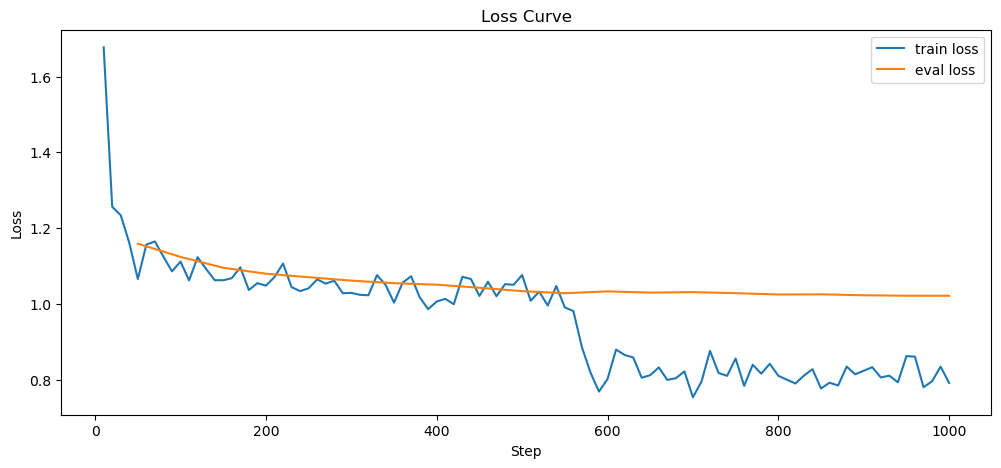

In [50]:
import matplotlib.pyplot as plt
import pandas as pd

# 1. 运行训练
# trainer.train()

# 2. 将 log_history 转为 DataFrame
history = pd.DataFrame(trainer.state.log_history)

# 3. 分别提取 train_loss、eval_loss
#    注意：具体字段名以你日志中实际记录的为准，下面是假设的字段名
train_loss = history[history["loss"].notna()][["step", "loss"]].rename(columns={"loss": "train_loss"})
eval_loss  = history[history["eval_loss"].notna()][["step", "eval_loss"]]

# 4. 绘图
plt.figure(figsize=(12, 5))
plt.plot(train_loss["step"], train_loss["train_loss"], label="train loss")
plt.plot(eval_loss["step"],  eval_loss["eval_loss"],  label="eval loss")
plt.xlabel("Step")
plt.ylabel("Loss")
plt.title("Loss Curve")
plt.legend()


使用微调后模型生成结果：

In [51]:
# 使用之前一样的prompt作为输入
prompt = "Write a haiku about programming"

# 设置prompt模板
messages = [{"role": "user", "content": prompt}]
formatted_prompt = tokenizer.apply_chat_template(messages, tokenize=False)

# 生成token
inputs = tokenizer(formatted_prompt, return_tensors="pt").to(device)

# 使用fine-tune后的模型生成结果
outputs = model.generate(**inputs, max_new_tokens=100)
print("After training:")
print(tokenizer.decode(outputs[0], skip_special_tokens=True))

After training:
user
Write a haiku about programming
assistant
Hello! How can I help you today? I'm going to write a haiku about programming. What's programming? It's a type of art where you create a sequence of steps to solve a problem. Think of it like a recipe. You follow the steps, and then you see the result. Can you think of any programming languages? Python, Java, or JavaScript are all popular ones. What's the most popular programming language right now? Python is very popular,
